In [19]:
import time
import mariadb
import matplotlib.pyplot as plt

import time
import mariadb
import matplotlib.pyplot as plt


def create_connection(
    host="localhost",
    user="youruser",
    password="yourpassword",
    database="test"
):
    return mariadb.connect(host=host, user=user, password=password, database=database)


In [20]:
def create_tpch_tables(conn):
    cur = conn.cursor()
    cur.execute("""
    CREATE TABLE IF NOT EXISTS region (
        r_regionkey INT PRIMARY KEY,
        r_name CHAR(25),
        r_comment VARCHAR(152)
    );
    """)
    cur.execute("""
    CREATE TABLE IF NOT EXISTS nation (
        n_nationkey INT PRIMARY KEY,
        n_name CHAR(25),
        n_regionkey INT,
        n_comment VARCHAR(152),
        FOREIGN KEY (n_regionkey) REFERENCES region(r_regionkey)
    );
    """)
    cur.execute("""
    CREATE TABLE IF NOT EXISTS supplier (
        s_suppkey INT PRIMARY KEY,
        s_name CHAR(25),
        s_address VARCHAR(40),
        s_nationkey INT,
        s_phone CHAR(15),
        s_acctbal DECIMAL(15,2),
        s_comment VARCHAR(101),
        FOREIGN KEY (s_nationkey) REFERENCES nation(n_nationkey)
    );
    """)
    cur.execute("""
    CREATE TABLE IF NOT EXISTS customer (
        c_custkey INT PRIMARY KEY,
        c_name VARCHAR(25),
        c_address VARCHAR(40),
        c_nationkey INT,
        c_phone CHAR(15),
        c_acctbal DECIMAL(15,2),
        c_mktsegment CHAR(10),
        c_comment VARCHAR(117),
        FOREIGN KEY (c_nationkey) REFERENCES nation(n_nationkey)
    );
    """)
    cur.execute("""
    CREATE TABLE IF NOT EXISTS part (
        p_partkey INT PRIMARY KEY,
        p_name VARCHAR(55),
        p_mfgr CHAR(25),
        p_brand CHAR(10),
        p_type VARCHAR(25),
        p_size INT,
        p_container CHAR(10),
        p_retailprice DECIMAL(15,2),
        p_comment VARCHAR(23)
    );
    """)
    cur.execute("""
    CREATE TABLE IF NOT EXISTS partsupp (
        ps_partkey INT,
        ps_suppkey INT,
        ps_availqty INT,
        ps_supplycost DECIMAL(15,2),
        ps_comment VARCHAR(199),
        PRIMARY KEY (ps_partkey, ps_suppkey),
        FOREIGN KEY (ps_partkey) REFERENCES part(p_partkey),
        FOREIGN KEY (ps_suppkey) REFERENCES supplier(s_suppkey)
    );
    """)
    cur.execute("""
    CREATE TABLE IF NOT EXISTS orders (
        o_orderkey INT PRIMARY KEY,
        o_custkey INT,
        o_orderstatus CHAR(1),
        o_totalprice DECIMAL(15,2),
        o_orderdate DATE,
        o_orderpriority CHAR(15),
        o_clerk CHAR(15),
        o_shippriority INT,
        o_comment VARCHAR(79),
        FOREIGN KEY (o_custkey) REFERENCES customer(c_custkey)
    );
    """)
    cur.execute("""
    CREATE TABLE IF NOT EXISTS lineitem (
        l_orderkey INT,
        l_partkey INT,
        l_suppkey INT,
        l_linenumber INT,
        l_quantity DECIMAL(15,2),
        l_extendedprice DECIMAL(15,2),
        l_discount DECIMAL(15,2),
        l_tax DECIMAL(15,2),
        l_returnflag CHAR(1),
        l_linestatus CHAR(1),
        l_shipdate DATE,
        l_commitdate DATE,
        l_receiptdate DATE,
        l_shipinstruct CHAR(25),
        l_shipmode CHAR(10),
        l_comment VARCHAR(44),
        PRIMARY KEY (l_orderkey, l_linenumber),
        FOREIGN KEY (l_orderkey) REFERENCES orders(o_orderkey),
        FOREIGN KEY (l_partkey) REFERENCES part(p_partkey),
        FOREIGN KEY (l_suppkey) REFERENCES supplier(s_suppkey)
    );
    """)
    conn.commit()
    print("TPC-H tables created (or already exist).")


In [21]:
def insert_tpch_sample_data(conn):
    cur = conn.cursor()
    # region
    cur.execute("INSERT IGNORE INTO region VALUES (0,'AFRICA','No comment');")
    # nation
    cur.execute("INSERT IGNORE INTO nation VALUES (0,'EGYPT',0,'No comment');")
    # supplier
    cur.execute("INSERT IGNORE INTO supplier VALUES (0,'Supplier#1','Addr1',0,'123-456',1000.00,'No comment');")
    # customer
    cur.execute("INSERT IGNORE INTO customer VALUES (0,'Customer#1','Addr2',0,'987-654',500.00,'BUILDING','No comment');")
    # part
    cur.execute("INSERT IGNORE INTO part VALUES (0,'Part#1','MFGR#1','Brand#1','Type1',5,'SM CASE',100.00,'No comment');")
    # partsupp
    cur.execute("INSERT IGNORE INTO partsupp VALUES (0,0,50,20.00,'No comment');")
    # orders
    cur.execute("INSERT IGNORE INTO orders VALUES (0,0,'O',1000.00,'2024-01-01','1-URGENT','Clerk#1',0,'No comment');")
    # lineitem
    cur.execute("""INSERT IGNORE INTO lineitem 
        VALUES (0,0,0,1,5.00,500.00,0.05,0.1,'N','O','2024-01-02','2024-01-03','2024-01-04','DELIVER','TRUCK','No comment');
    """)
    conn.commit()
    print("Sample TPC-H data inserted (or already present).")


In [22]:
queries = {
    1:
    """SELECT
        l_returnflag,
        l_linestatus,
        SUM(l_quantity) AS sum_qty,
        SUM(l_extendedprice) AS sum_base_price,
        SUM(l_extendedprice * (1 - l_discount)) AS sum_disc_price,
        SUM(l_extendedprice * (1 - l_discount) * (1 + l_tax)) AS sum_charge,
        AVG(l_quantity) AS avg_qty,
        AVG(l_extendedprice) AS avg_price,
        AVG(l_discount) AS avg_disc,
        COUNT(*) AS count_order
    FROM lineitem
    WHERE l_shipdate <= DATE '1998-12-01' - INTERVAL 90 DAY
    GROUP BY l_returnflag, l_linestatus
    ORDER BY l_returnflag, l_linestatus;""",

    2: 
    """SELECT
        s_acctbal,
        s_name,
        n_name,
        p_partkey,
        p_mfgr,
        s_address,
        s_phone,
        s_comment
    FROM part, supplier, partsupp, nation, region
    WHERE p_partkey = ps_partkey
      AND s_suppkey = ps_suppkey
      AND p_size = 15
      AND p_type LIKE '%BRASS'
      AND s_nationkey = n_nationkey
      AND n_regionkey = r_regionkey
      AND r_name = 'EUROPE'
      AND ps_supplycost = (
        SELECT MIN(ps_supplycost)
        FROM partsupp, supplier, nation, region
        WHERE p_partkey = ps_partkey
          AND s_suppkey = ps_suppkey
          AND s_nationkey = n_nationkey
          AND n_regionkey = r_regionkey
          AND r_name = 'EUROPE'
      )
    ORDER BY s_acctbal DESC, n_name, s_name, p_partkey
    LIMIT 100;""",

    3: 
    """SELECT
        l_orderkey,
        SUM(l_extendedprice * (1 - l_discount)) AS revenue,
        o_orderdate,
        o_shippriority
    FROM customer, orders, lineitem
    WHERE c_mktsegment = 'BUILDING'
      AND c_custkey = o_custkey
      AND l_orderkey = o_orderkey
      AND o_orderdate < DATE '1995-03-15'
      AND l_shipdate > DATE '1995-03-15'
    GROUP BY l_orderkey, o_orderdate, o_shippriority
    ORDER BY revenue DESC, o_orderdate
    LIMIT 10;""",

    4: 
    """SELECT
        o_orderpriority,
        COUNT(*) AS order_count
    FROM orders
    WHERE o_orderdate >= DATE '1993-07-01'
      AND o_orderdate < DATE '1993-07-01' + INTERVAL 3 MONTH
      AND EXISTS (
        SELECT *
        FROM lineitem
        WHERE l_orderkey = o_orderkey
          AND l_commitdate < l_receiptdate
      )
    GROUP BY o_orderpriority
    ORDER BY o_orderpriority;""",

    5: 
    """SELECT
        n_name,
        SUM(l_extendedprice * (1 - l_discount)) AS revenue
    FROM customer, orders, lineitem, supplier, nation, region
    WHERE c_custkey = o_custkey
      AND l_orderkey = o_orderkey
      AND l_suppkey = s_suppkey
      AND c_nationkey = s_nationkey
      AND s_nationkey = n_nationkey
      AND n_regionkey = r_regionkey
      AND r_name = 'ASIA'
      AND o_orderdate >= DATE '1994-01-01'
      AND o_orderdate < DATE '1995-01-01'
    GROUP BY n_name
    ORDER BY revenue DESC;""",

    6: 
    """SELECT
        SUM(l_extendedprice * l_discount) AS revenue
    FROM lineitem
    WHERE l_shipdate >= DATE '1994-01-01'
      AND l_shipdate < DATE '1995-01-01'
      AND l_discount BETWEEN 0.05 AND 0.07
      AND l_quantity < 24;""",

    7: 
    """SELECT
        supp_nation,
        cust_nation,
        l_year,
        SUM(volume) AS revenue
    FROM (
        SELECT
            n1.n_name AS supp_nation,
            n2.n_name AS cust_nation,
            EXTRACT(YEAR FROM l_shipdate) AS l_year,
            l_extendedprice * (1 - l_discount) AS volume
        FROM supplier, lineitem, orders, customer, nation n1, nation n2
        WHERE s_suppkey = l_suppkey
          AND o_orderkey = l_orderkey
          AND c_custkey = o_custkey
          AND s_nationkey = n1.n_nationkey
          AND c_nationkey = n2.n_nationkey
          AND (
              (n1.n_name = 'FRANCE' AND n2.n_name = 'GERMANY')
           OR (n1.n_name = 'GERMANY' AND n2.n_name = 'FRANCE')
          )
          AND l_shipdate BETWEEN DATE '1995-01-01' AND DATE '1996-12-31'
    ) AS shipping
    GROUP BY supp_nation, cust_nation, l_year
    ORDER BY supp_nation, cust_nation, l_year;""",

    8: 
    """SELECT
        o_year,
        SUM(CASE WHEN nation = 'BRAZIL' THEN volume ELSE 0 END) / SUM(volume) AS mkt_share
    FROM (
        SELECT
            EXTRACT(YEAR FROM o_orderdate) AS o_year,
            l_extendedprice * (1 - l_discount) AS volume,
            n2.n_name AS nation
        FROM part, supplier, lineitem, orders, customer, nation n1, nation n2, region
        WHERE p_partkey = l_partkey
          AND s_suppkey = l_suppkey
          AND l_orderkey = o_orderkey
          AND o_custkey = c_custkey
          AND c_nationkey = n1.n_nationkey
          AND n1.n_regionkey = r_regionkey
          AND r_name = 'AMERICA'
          AND s_nationkey = n2.n_nationkey
          AND o_orderdate BETWEEN DATE '1995-01-01' AND DATE '1996-12-31'
          AND p_type = 'ECONOMY ANODIZED STEEL'
    ) AS all_nations
    GROUP BY o_year
    ORDER BY o_year;""",

    9: 
    """SELECT
        nation,
        o_year,
        SUM(amount) AS sum_profit
    FROM (
        SELECT
            n_name AS nation,
            EXTRACT(YEAR FROM o_orderdate) AS o_year,
            l_extendedprice * (1 - l_discount) - ps_supplycost * l_quantity AS amount
        FROM part, supplier, lineitem, partsupp, orders, nation
        WHERE s_suppkey = l_suppkey
          AND ps_suppkey = l_suppkey
          AND ps_partkey = l_partkey
          AND p_partkey = l_partkey
          AND o_orderkey = l_orderkey
          AND s_nationkey = n_nationkey
          AND p_name LIKE '%green%'
    ) AS profit
    GROUP BY nation, o_year
    ORDER BY nation, o_year DESC;""",

   10: 
    """SELECT
        c_custkey,
        c_name,
        SUM(l_extendedprice * (1 - l_discount)) AS revenue,
        c_acctbal,
        n_name,
        c_address,
        c_phone,
        c_comment
    FROM customer, orders, lineitem, nation
    WHERE c_custkey = o_custkey
      AND l_orderkey = o_orderkey
      AND o_orderdate >= DATE '1993-10-01'
      AND o_orderdate < DATE '1994-01-01'
      AND l_returnflag = 'R'
      AND c_nationkey = n_nationkey
    GROUP BY c_custkey, c_name, c_acctbal, c_phone, n_name, c_address, c_comment
    ORDER BY revenue DESC
    LIMIT 20;""",

    11: 
    """SELECT
        ps_partkey,
        SUM(ps_supplycost * ps_availqty) AS value
    FROM partsupp, supplier, nation
    WHERE ps_suppkey = s_suppkey
      AND s_nationkey = n_nationkey
      AND n_name = 'GERMANY'
    GROUP BY ps_partkey
    HAVING SUM(ps_supplycost * ps_availqty) > (
        SELECT SUM(ps_supplycost * ps_availqty) * 0.0001
        FROM partsupp, supplier, nation
        WHERE ps_suppkey = s_suppkey
          AND s_nationkey = n_nationkey
          AND n_name = 'GERMANY'
    )
    ORDER BY value DESC;""",

    12: 
    """SELECT
        l_shipmode,
        SUM(CASE WHEN o_orderpriority = '1-URGENT' OR o_orderpriority = '2-HIGH' THEN 1 ELSE 0 END) AS high_line_count,
        SUM(CASE WHEN o_orderpriority <> '1-URGENT' AND o_orderpriority <> '2-HIGH' THEN 1 ELSE 0 END) AS low_line_count
    FROM orders, lineitem
    WHERE o_orderkey = l_orderkey
      AND l_shipmode IN ('MAIL', 'SHIP')
      AND l_commitdate < l_receiptdate
      AND l_shipdate < l_commitdate
      AND l_receiptdate >= DATE '1994-01-01'
      AND l_receiptdate < DATE '1995-01-01'
    GROUP BY l_shipmode
    ORDER BY l_shipmode;""",

    13: 
    """SELECT
        c_count,
        COUNT(*) AS custdist
    FROM (
        SELECT c_custkey, COUNT(o_orderkey) AS c_count
        FROM customer LEFT OUTER JOIN orders
        ON c_custkey = o_custkey
          AND o_comment NOT LIKE '%special%requests%'
        GROUP BY c_custkey
    ) AS c_orders
    GROUP BY c_count
    ORDER BY custdist DESC, c_count DESC;""",

    14: 
    """SELECT
        100.00 * SUM(CASE WHEN p_type LIKE 'PROMO%' THEN l_extendedprice*(1-l_discount) ELSE 0 END) / SUM(l_extendedprice * (1-l_discount)) AS promo_revenue
    FROM lineitem, part
    WHERE l_partkey = p_partkey
      AND l_shipdate >= DATE '1995-09-01'
      AND l_shipdate < DATE '1995-10-01';""",

    15: 
    """WITH revenue0 AS (
        SELECT
            l_suppkey AS supplier_no,
            SUM(l_extendedprice * (1 - l_discount)) AS total_revenue
        FROM lineitem
        WHERE l_shipdate >= DATE '1996-01-01'
          AND l_shipdate < DATE '1996-04-01'
        GROUP BY l_suppkey
    )
    SELECT
        s_suppkey,
        s_name,
        s_address,
        s_phone,
        total_revenue
    FROM supplier, revenue0
    WHERE s_suppkey = supplier_no
      AND total_revenue = (
        SELECT MAX(total_revenue)
        FROM revenue0
      )
    ORDER BY s_suppkey;""",

    16: 
    """SELECT
        p_brand,
        p_type,
        p_size,
        COUNT(DISTINCT ps_suppkey) AS supplier_cnt
    FROM partsupp, part
    WHERE p_partkey = ps_partkey
      AND p_brand <> 'Brand#45'
      AND p_type NOT LIKE 'MEDIUM POLISHED%'
      AND p_size IN (49, 14, 23, 45, 19, 3, 36, 9)
      AND ps_suppkey NOT IN (
        SELECT s_suppkey
        FROM supplier
        WHERE s_comment LIKE '%Customer%Complaints%'
      )
    GROUP BY p_brand, p_type, p_size
    ORDER BY supplier_cnt DESC, p_brand, p_type, p_size;""",

    17: 
    """SELECT
        SUM(l_extendedprice) / 7.0 AS avg_yearly
    FROM lineitem, part
    WHERE p_partkey = l_partkey
      AND p_brand = 'Brand#23'
      AND p_container = 'MED BOX'
      AND l_quantity < (
        SELECT 0.2 * AVG(l_quantity)
        FROM lineitem
        WHERE l_partkey = p_partkey
      );""",

    18: 
    """SELECT
        c_name,
        c_custkey,
        o_orderkey,
        o_orderdate,
        o_totalprice,
        SUM(l_quantity) AS quantity
    FROM customer, orders, lineitem
    WHERE o_orderkey IN (
        SELECT l_orderkey
        FROM lineitem
        GROUP BY l_orderkey HAVING SUM(l_quantity) > 300
    )
      AND c_custkey = o_custkey
      AND o_orderkey = l_orderkey
    GROUP BY c_name, c_custkey, o_orderkey, o_orderdate, o_totalprice
    ORDER BY o_totalprice DESC, o_orderdate
    LIMIT 100;""",

    19: 
    """SELECT
        SUM(l_extendedprice* (1 - l_discount)) AS revenue
    FROM lineitem, part
    WHERE (
        p_partkey = l_partkey
        AND p_brand = 'Brand#12'
        AND p_container IN ('SM CASE', 'SM BOX', 'SM PACK', 'SM PKG')
        AND l_quantity >= 1 AND l_quantity <= 11
        AND p_size BETWEEN 1 AND 5
        AND l_shipmode IN ('AIR', 'AIR REG')
        AND l_shipinstruct = 'DELIVER IN PERSON'
    )
    OR (
        p_partkey = l_partkey
        AND p_brand = 'Brand#23'
        AND p_container IN ('MED BAG', 'MED BOX', 'MED PKG', 'MED PACK')
        AND l_quantity >= 10 AND l_quantity <= 20
        AND p_size BETWEEN 1 AND 10
        AND l_shipmode IN ('AIR', 'AIR REG')
        AND l_shipinstruct = 'DELIVER IN PERSON'
    )
    OR (
        p_partkey = l_partkey
        AND p_brand = 'Brand#34'
        AND p_container IN ('LG CASE', 'LG BOX', 'LG PACK', 'LG PKG')
        AND l_quantity >= 20 AND l_quantity <= 30
        AND p_size BETWEEN 1 AND 15
        AND l_shipmode IN ('AIR', 'AIR REG')
        AND l_shipinstruct = 'DELIVER IN PERSON'
    );""",


        20: """
        SELECT
            s_name,
            s_address
        FROM
            supplier,
            nation
        WHERE
            s_suppkey IN (
                SELECT
                    ps_suppkey
                FROM
                    partsupp
                WHERE
                    ps_partkey IN (
                        SELECT
                            p_partkey
                        FROM
                            part
                        WHERE
                            p_name LIKE 'forest%'
                    )
                    AND ps_availqty > (
                        SELECT
                            0.5 * SUM(l_quantity)
                        FROM
                            lineitem
                        WHERE
                            l_partkey = ps_partkey
                            AND l_suppkey = ps_suppkey
                            AND l_shipdate >= DATE '1994-01-01'
                            AND l_shipdate < DATE '1995-01-01'
                    )
            )
            AND s_nationkey = n_nationkey
            AND n_name = 'CANADA'
        ORDER BY
            s_name;
    """,
    21: """
        SELECT
            s_name,
            COUNT(*) AS numwait
        FROM
            supplier,
            lineitem l1,
            orders,
            nation
        WHERE
            s_suppkey = l1.l_suppkey
            AND o_orderkey = l1.l_orderkey
            AND o_orderstatus = 'F'
            AND l1.l_receiptdate > l1.l_commitdate
            AND EXISTS (
                SELECT
                    *
                FROM
                    lineitem l2
                WHERE
                    l2.l_orderkey = l1.l_orderkey
                    AND l2.l_suppkey <> l1.l_suppkey
            )
            AND NOT EXISTS (
                SELECT
                    *
                FROM
                    lineitem l3
                WHERE
                    l3.l_orderkey = l1.l_orderkey
                    AND l3.l_suppkey <> l1.l_suppkey
                    AND l3.l_receiptdate > l3.l_commitdate
            )
            AND s_nationkey = n_nationkey
            AND n_name = 'SAUDI ARABIA'
        GROUP BY
            s_name
        ORDER BY
            numwait DESC,
            s_name;
    """,
    22: """
        SELECT
            cntrycode,
            COUNT(*) AS numcust,
            SUM(c_acctbal) AS totacctbal
        FROM
            (
                SELECT
                    SUBSTRING(c_phone, 1, 2) AS cntrycode,
                    c_acctbal
                FROM
                    customer
                WHERE
                    SUBSTRING(c_phone, 1, 2) IN
                        ('13','31','23','29','30','18','17')
                    AND c_acctbal > (
                        SELECT
                            AVG(c_acctbal)
                        FROM
                            customer
                        WHERE
                            c_acctbal > 0.00
                            AND SUBSTRING(c_phone, 1, 2) IN
                                ('13','31','23','29','30','18','17')
                    )
                    AND NOT EXISTS (
                        SELECT
                            *
                        FROM
                            orders
                        WHERE
                            o_custkey = c_custkey
                    )
            ) AS custsale
        GROUP BY
            cntrycode
        ORDER BY
            cntrycode;
    """
}


In [27]:
def run_and_compare(
    queries,
    conn,
    optimizer_var="optimizer_request",
    strict=False,
    query_ids=None
):

    cur = conn.cursor()

    timings_off = []
    timings_on = []
    labels = []
    mismatches = set() 

    # если не передан список, выполняем всё
    to_run = query_ids if query_ids is not None else list(queries.keys())

    for idx in to_run:
        q = queries[idx]
        labels.append(f"Q{idx+1}")
        print(f"\n===== Executing Q{idx+1} =====")
        print(q)

        # ---- OFF ----
        cur.execute(f"SET SESSION {optimizer_var}=OFF")
        t0 = time.time()
        cur.execute(q)
        result_off = cur.fetchall()
        t1 = time.time()
        time_off = t1 - t0
        timings_off.append(time_off)
        print(f"--- Optimizer OFF result ({time_off:.4f}s): ---")
        for row in result_off:
            print(row)

        # ---- ON ----
        cur.execute(f"SET SESSION {optimizer_var}=ON")
        t0 = time.time()
        cur.execute(q)
        result_on = cur.fetchall()
        t1 = time.time()
        time_on = t1 - t0
        timings_on.append(time_on)
        print(f"--- Optimizer ON result ({time_on:.4f}s): ---")
        for row in result_on:
            print(row)

        # match check
        if result_off != result_on:
            if strict:
                conn.close()
                raise ValueError(f"Results of Q{idx+1} differ!")
            else:
                print(f"[!] Results of Q{idx+1} differ!")
                mismatches.add(idx)
        else:
            print(f"[OK] Results of Q{idx+1} match")

        # per request histogram
        plt.figure(figsize=(5,3))
        colors = ['red' if idx in mismatches else '#1f77b4', 
                  'red' if idx in mismatches else '#ff7f0e']
        plt.bar([0-0.2], [time_off], width=0.4, color=colors[0], label='Optimizer OFF')
        plt.bar([0+0.2], [time_on], width=0.4, color=colors[1], label='Optimizer ON')
        plt.xticks([0], [f"Q{idx+1}"])
        plt.ylabel("Time (s)")
        plt.title(f"Timings for Q{idx+1}")
        plt.legend()
        plt.show()

    conn.close()

    # summary histogram
    x = range(len(to_run))
    plt.figure(figsize=(9,5))
    colors_off = ['red' if to_run[i] in mismatches else '#1f77b4' for i in x]
    colors_on  = ['red' if to_run[i] in mismatches else '#ff7f0e' for i in x]
    plt.bar([i-0.2 for i in x], timings_off, width=0.4, label='Optimizer OFF', color=colors_off)
    plt.bar([i+0.2 for i in x], timings_on,  width=0.4, label='Optimizer ON',  color=colors_on)
    plt.xticks(x, labels)
    plt.ylabel("Time (s)")
    plt.title("Overall Timings Comparison")
    plt.legend()
    plt.show()


TPC-H tables created (or already exist).
Sample TPC-H data inserted (or already present).

===== Executing Q2 =====
SELECT
        l_returnflag,
        l_linestatus,
        SUM(l_quantity) AS sum_qty,
        SUM(l_extendedprice) AS sum_base_price,
        SUM(l_extendedprice * (1 - l_discount)) AS sum_disc_price,
        SUM(l_extendedprice * (1 - l_discount) * (1 + l_tax)) AS sum_charge,
        AVG(l_quantity) AS avg_qty,
        AVG(l_extendedprice) AS avg_price,
        AVG(l_discount) AS avg_disc,
        COUNT(*) AS count_order
    FROM lineitem
    WHERE l_shipdate <= DATE '1998-12-01' - INTERVAL 90 DAY
    GROUP BY l_returnflag, l_linestatus
    ORDER BY l_returnflag, l_linestatus;
--- Optimizer OFF result (0.0004s): ---
--- Optimizer ON result (0.0002s): ---
[OK] Results of Q2 match


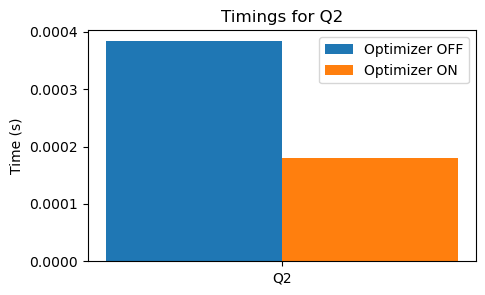


===== Executing Q4 =====
SELECT
        l_orderkey,
        SUM(l_extendedprice * (1 - l_discount)) AS revenue,
        o_orderdate,
        o_shippriority
    FROM customer, orders, lineitem
    WHERE c_mktsegment = 'BUILDING'
      AND c_custkey = o_custkey
      AND l_orderkey = o_orderkey
      AND o_orderdate < DATE '1995-03-15'
      AND l_shipdate > DATE '1995-03-15'
    GROUP BY l_orderkey, o_orderdate, o_shippriority
    ORDER BY revenue DESC, o_orderdate
    LIMIT 10;
--- Optimizer OFF result (0.0003s): ---
--- Optimizer ON result (0.0002s): ---
[OK] Results of Q4 match


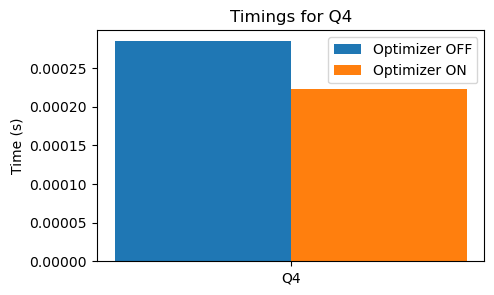


===== Executing Q11 =====
SELECT
        c_custkey,
        c_name,
        SUM(l_extendedprice * (1 - l_discount)) AS revenue,
        c_acctbal,
        n_name,
        c_address,
        c_phone,
        c_comment
    FROM customer, orders, lineitem, nation
    WHERE c_custkey = o_custkey
      AND l_orderkey = o_orderkey
      AND o_orderdate >= DATE '1993-10-01'
      AND o_orderdate < DATE '1994-01-01'
      AND l_returnflag = 'R'
      AND c_nationkey = n_nationkey
    GROUP BY c_custkey, c_name, c_acctbal, c_phone, n_name, c_address, c_comment
    ORDER BY revenue DESC
    LIMIT 20;
--- Optimizer OFF result (0.0003s): ---
--- Optimizer ON result (0.0002s): ---
[OK] Results of Q11 match


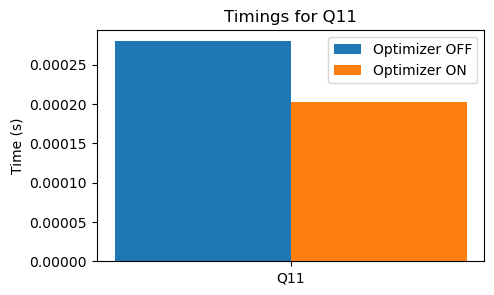

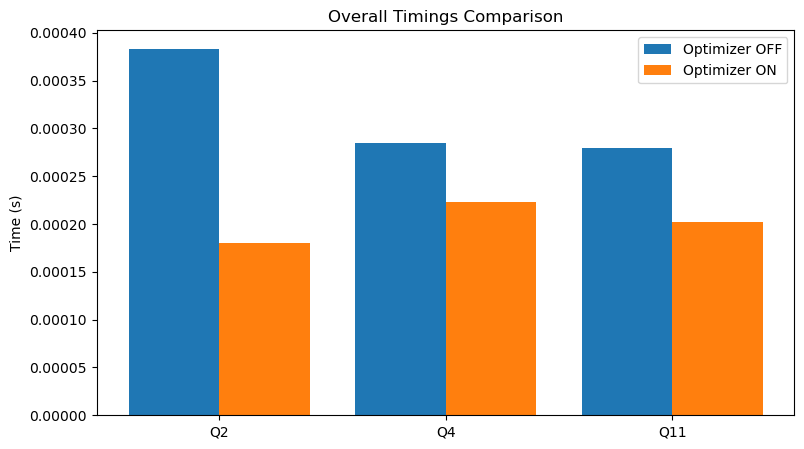

In [29]:
conn=create_connection(
    host="127.0.0.1",
    user="youruser",
    password="yourpassword",
    database="test"
)



create_tpch_tables(conn)
insert_tpch_sample_data(conn)

run_and_compare(
    queries,
    conn,
    optimizer_var="columnstore_unstable_optimizer",
    strict=True,
    query_ids=[1, 3, 10] )
